<a href="https://colab.research.google.com/github/chandolkarim/chandolkarim.github.io/blob/main/BizMLLab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

비즈니스머신러닝 2강

## **1. MultiLinear Regression 연습**

먼저 시험점수와 SNS의 상관 관계를 분석하는 데이터를 실습해 봅시다. 지난시간과 마찬가지로 데이터를 각각 numpy의 행렬로 표시합니다.
PPT 43 page의 데이터중 화면에 보이는 4개의 데이터만 가지고 학습하겠습니다.

In [ ]:
import numpy as np
from numpy.linalg import inv
from numpy.linalg import pinv

In [ ]:
A = np.array([[10,95,1],[80,20,1],[50,60,1],[40,50,1]]) # 절편까지 고려하겠습니다.
b = np.array([90,10,85,50])

In [ ]:
print(A)

A 행렬이 정사각형 행렬이 아니므로 (행렬의 열의 개수와 행의 개수가 불일치 하기 때문에) 일반적인 inv로 계산을 할 수 없습니다. 그러므로 ppt 61 page의 방법을 사용하겠습니다.

In [ ]:
Apinv = inv(A.T @ A) @ A.T
print(Apinv)

#또는 numpy에서 제공하는 기능을 사용할 수도 있습니다.
Apinv2 = pinv(A)
print(Apinv2)

In [ ]:
x = Apinv @ b
print(x)

- 위 계수를 통해 SNS시간과 직전점수가 각각 시험점수에 어떤 영향을 나타내는지 설명해 보세요
- 내가 하는 SNS 시간 및 직전 점수를 임력해서 자신의 점수를 예측해 보세요

In [ ]:
np.linalg.cond(A)

In [ ]:
mydata = [30, 50,1]
print(np.dot(mydata, x))


실제 나온 결과치 (계수)가 원 데이터를 얼마나 잘 설명하고 있는지 performance를 계산해 보세요, MSE와 MAE를 각각 계산해 보세요

In [ ]:
bp = A @ x
print(bp)
MSE = np.linalg.norm(b-bp)**2/b.shape[0]

MAE = np.linalg.norm(b-bp, ord = 1) / b.shape[0]

print('MSE는 ', MSE)
print('MAE는 ',MAE)

역행렬을 계산하는 것은 너무 복잡하고 어려우니 이번에는 최적화 방법 (gradient descent)를 이용해서 계산해 볼까요?

In [ ]:
# 1. 먼저 아무 초기값이나 임의로 정합니다.

x0 = np.array([0,0,-100])

In [ ]:
# 2. 초기값으로부터 계속 반복하여 조금씩 이동해 볼꺼에요 step length 변수 s는 일단 1로 잡았는데요, 적절한 값으로 변경해 보세요...

from numpy.linalg import norm

xt = x0

s = 0.00001
xold = xt
err = []
for i in range(10000):
  p = 2*np.dot(A.T, (np.dot(A, xt) - b))
  xt = xt - s * p

  # 계수의 변화량 (err 변수)이 크게 의미없이 되었을 때 (수렴했을때) 그만 돌릴겁니다.
  err.append(norm(xt-xold))
#  print('%d th iteration error = %f'%(i,err[-1]))
  if err[-1] < 1.0e-4:  # 정밀도가 1.0e-4까지 허용할 예정입니다.
    print('converged')
    break
  xold = xt

print('계수 계산 결과 : ', xt)
print('수렴 횟수 : ',i)

[  0.98383372   1.97459584 -96.59353349]

In [ ]:
bp = A @ xt
print(b-bp)
MSE = np.linalg.norm(b-bp)**2/b.shape[0]

MAE = np.linalg.norm(b-bp, ord = 1) / b.shape[0]

print(bp)
print('MSE는 ', MSE)
print('MAE는 ',MAE)

## **2. Multilinear Regression 실데이터 실습**


실전 데이터를 사용하여 Multilinear Regression 실습을 진행합니다.
데이터는 보스턴의 집값 데이터를 사용합니다.

일반적으로 정리가 끝난 데이터는 테이블 형태의 구조화된 파일에 저장이 됩니다. (2단계에서) excel을 이용하여 정리된 파일을 읽어 오겠습니다. 로컬에서 읽으면 불편하고 다른 곳에서는 실행이 안될테니 데이터 파일을 클라우드에 저장한 후 읽어 오겠습니다. 먼저 클라우드 공간을 마치 로컬 저장 공간인 것 처럼 연결합니다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


로컬 하드 드라이브에 있는 C, D 드라이브처럼 구글 드라이브를 연결해서 쓸 수 있습니다. 그 후 저장된 실습 파일이 있는 폴더로 이동합니다. pandas 모듈을 이용하여 csv 파일을 자동으로 읽은 후 테이블 형태의 데이터로 저장하겠습니다

In [ ]:
cd drive/My\ Drive/Colab\ Notebooks/2026-2BizML

/content/drive/My Drive/Colab Notebooks/2026-2BizML


In [ ]:
import pandas as pd
import numpy as np
from sklearn import datasets

raw_df = pd.read_csv('HousingData.csv')

In [ ]:
raw_df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

### 변수 설명
- CRIM:	자치시(town) 별 1인당 범죄율
- ZN: 25,000 평방피트를 초과하는 거주지역의 비율
- INDUS: 비소매상업지역이 점유하고 있는 토지의 비율
- CHAS: 찰스강에 대한 더미변수(강의 경계에 위치한 경우는 1, 아니면 0)
- NOX: 10ppm 당 농축 일산화질소
- RM: 주택 1가구당 평균 방의 개수
- AGE: 1940년 이전에 건축된 소유주택의 비율
- DIS: 5개의 보스턴 직업센터까지의 접근성 지수
- RAD: 방사형 도로까지의 접근성 지수
- TAX: 10,000 달러 당 재산세율
- PTRATIO: 자치시(town)별 학생/교사 비율
- B: 1000(Bk-0.63)^2, 여기서 Bk는 자치시별 흑인의 비율을 말함.
- LSTAT: 모집단의 하위계층의 비율(%)
- MEDV: 본인 소유의 주택가격(중앙값) (단위: $1,000)

여기에서 MEDV는 학습에 이용하지 않음

In [ ]:
## Boston dataset을 pandas.DataFrame으로 변환
data = pd.DataFrame(raw_df, columns=['CRIM','ZN','INDUS','CHAS', 'NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT'])

data['PRICE'] = pd.DataFrame(raw_df, columns=['MEDV'])

In [ ]:
data.shape

(506, 14)

2단계 전처리를 해 보겠습니다. 거창한 건 안하고 일단 돌아가는것만 확인해야 하기 때문에 먼저 missing value나 outlier가 있는지만 확인하겠습니다.

In [ ]:
data.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [ ]:
# missing value가 있는 column들이 있네요. 어떻게 할까요? 일단 몇개 안되니 날려버리겠습니다.
data = data.dropna(axis=0)

In [ ]:
print("Size of Boston datsaet: ", data.shape)

Size of Boston datsaet:  (394, 14)


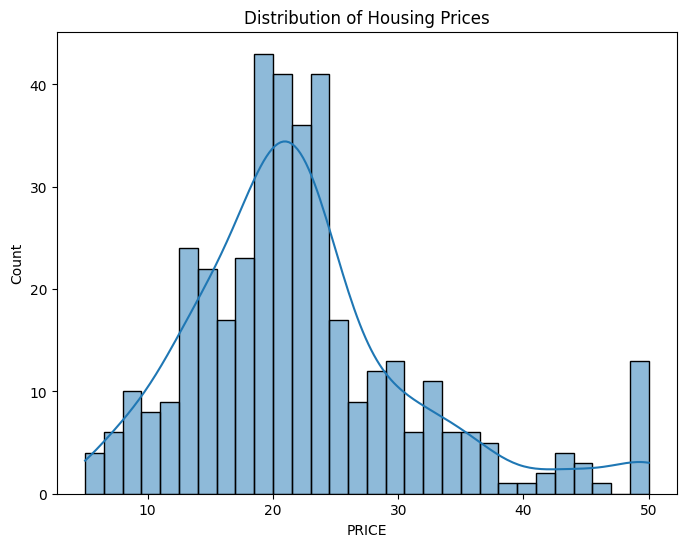

In [ ]:
# outlier 확인을 다 하기 어려우니 target value값의 분포가 어떤지만 보겠습니다.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='PRICE', bins=30, kde=True)
plt.title('Distribution of Housing Prices')
plt.show()

In [ ]:
# outlier가 있을까요?
# 데이터가 어떻게 생겼는지 첫 10개만 화면에 출력해 보겠습니다.

data.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
10,0.22489,12.5,7.87,0.0,0.524,6.377,94.3,6.3467,5,311,15.2,392.52,20.45,15.0
11,0.11747,12.5,7.87,0.0,0.524,6.009,82.9,6.2267,5,311,15.2,396.90,13.27,18.9
12,0.09378,12.5,7.87,0.0,0.524,5.889,39.0,5.4509,5,311,15.2,390.50,15.71,21.7


본격적으로 회귀 모델을 학습해 봅니다.
현재 데이터가 하나의 행렬로 되어 있으니 독립변수와 종속변수로 분리합니다.
또한 직접 공식을 통해 계산하기 보다는 python에서 제공하는 라이브러리를 이용하여 계산해 봅니다.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
A = data.drop('PRICE', axis = 1, inplace = False) # 데이터셋에서 가격 정보를 분리한 후 독립변수로 지정
b = data['PRICE']  # 데이터의 가격정보만 종속변수로 지정

In [ ]:
model = LinearRegression() # 모델 선언

In [ ]:
model.fit(A, b) # 모델을 이용하여 데이터를 학습

LinearRegression()

In [ ]:
coef = pd.Series(data = model.coef_, index = A.columns) # 회귀 계수 (위의 예에서는 x 벡터)
print(coef)

CRIM       -0.097594
ZN          0.048905
INDUS       0.030379
CHAS        2.769378
NOX       -17.969028
RM          4.283252
AGE        -0.012991
DIS        -1.458510
RAD         0.285866
TAX        -0.013146
PTRATIO    -0.914582
B           0.009656
LSTAT      -0.423661
dtype: float64


In [ ]:
print(model.intercept_) #절편

32.680058543306174


위 계수를 통해 독립변수가 각각 집값에 어떤 영향을 나타내는지 설명해 보세요

## **학습 모델의 performance를 평가해 봅니다.**
sklearn 모듈에서는 linearRegression 뿐만 아니라 평가를 위한 여러가지 지표를 계산하는 다양한 기능을 제공하고 있습니다.

In [ ]:
from sklearn import metrics

In [ ]:
b_pred = model.predict(A)

In [ ]:
mse = metrics.mean_squared_error(b, b_pred)
rmse = np.sqrt(mse)

print('MSE: ', mse)
print('RMSE: ', rmse)

MSE:  19.418397930734912
RMSE:  4.406631131684942


In [ ]:
## MAE
mae = metrics.mean_absolute_error(b, b_pred)
print('MAE: ', mae)

MAE:  3.0644294828277836


그리고 임의의 집 정보를 입력해서 예상되는 집의 가격을 계산해 보시오.

In [ ]:
mydata = {}
mydata['CRIM'] = 0.0001
mydata['ZN'] = 0
mydata['INDUS'] = 2.3
mydata['CHAS'] = 1
mydata['NOX'] = 0.1
mydata['RM'] = 3
mydata['AGE'] = 10
mydata['DIS'] = 5
mydata['RAD'] = 2
mydata['TAX'] = 200
mydata['PTRATIO'] = 20
mydata['B'] = 0
mydata['LSTAT'] = 20
mynpdata = np.array([list(mydata.values())])
mypdata = pd.DataFrame(mynpdata, columns=A.columns)

myprice = model.predict(mypdata)
print('예상 집값은 ',myprice)

예상 집값은  [10.32727899]


In [ ]:
# 위 과정이 귀찮으시면 그냥 np array를 사용하셔도 됩니다.
# 대신 np.array를 이차원 배열로 만들어 주시는 거 잊지 마세요

mydata = np.array([[0.0001, 0, 2.3, 1,0.1, 3, 10, 5, 2, 200, 20, 0, 20]])
myprice = model.predict(mydata)
print('예상 집값은 ',myprice)

## **숙제!**

1챕터에 있는 시험점수와 SNS의 상관관계 데이터를 sklearn의 LinearRegression 모듈을 이용하여 계산해 보시고 계수와 절편을 직접 계산한 결과를 비교해 보세요

그리고 임의의 데이터를 입력하여 예상되는 성적을 계산해 보세요


In [ ]:
HW = pd.DataFrame({'SNS 시간': [10,80, 50, 40], '직전시험점수':[95,20,60,50], '시험점수':[90,10,85,50]})

HW

,SNS 시간,직전시험점수,시험점수
0,10,95,90
1,80,20,10
2,50,60,85
3,40,50,50


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
A = HW.drop('PRICE', axis = 1, inplace = False) # 데이터셋에서 가격 정보를 분리한 후 독립변수로 지정
b = HW['ㅅ험점수']  # 데이터의 가격정보만 종속변수로 지정

KeyError: "['PRICE'] not found in axis"